In [338]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [339]:
df_5 = pd.read_csv("../data/processed/df_final (5).csv")

df_5

,Municipio,Delitos,Año,Periodo,Trimestre,Provincia,Total,Valor trimestral
0,Alaquàs,Delitos Sexuales,2021,Enero-Marzo,1,Valencia,2,2.0
1,Alaquàs,Delitos Sexuales,2021,Enero-Junio,2,Valencia,2,0.0
2,Alaquàs,Delitos Sexuales,2021,Enero-Septiembre,3,Valencia,2,0.0
3,Alaquàs,Delitos Sexuales,2021,Enero-Diciembre,4,Valencia,4,2.0
4,Alaquàs,Delitos Sexuales,2022,Enero-Marzo,1,Valencia,0,0.0
...,...,...,...,...,...,...,...,...
35593,Xàtiva,Trafico De Drogas,2024,Enero-Septiembre,3,Valencia,2,0.0
35594,Xàtiva,Trafico De Drogas,2024,Enero-Diciembre,4,Valencia,4,2.0
35595,Xàtiva,Trafico De Drogas,2025,Enero-Marzo,1,Valencia,2,2.0
35596,Xàtiva,Trafico De Drogas,2025,Enero-Junio,2,Valencia,3,1.0


# Análisis Univariante. 

> - La variable objetivo `Total` representa el número total de delitos registrados por tipología, ámbito geográfico y periodo temporal. Su distribución presenta una fuerte asimetría positiva, con una elevada concentración de valores bajos y la presencia de valores extremos, lo cual es característico de variables de conteo asociadas a fenómenos poco frecuentes en determinadas combinaciones espaciales y temporales. 

In [340]:
df_5['Total'].describe().T

count     35598.000000
mean        279.435867
std        2899.502873
min           0.000000
25%           2.000000
50%          13.000000
75%          74.000000
max      112272.000000
Name: Total, dtype: float64

La variable objetivo `Total` presenta una distribución fuertemente asimétrica a la derecha. La media (297,4) es superior a la mediana (16), lo que indica la presencia de valores extremos que concentran gran parte del volumen total de delitos. Asimismo, el 75% de los registros presenta valores inferiores a 91, mientras que el valor máximo alcanza los 112,272 delitos. Esta elevada dispersión, junto con la presencia de numerosos valores bajos y nulos, es característica de variables de conteo asociadas a fenómenos heterogéneos en el espacio y el tiempo

# ANÁLISIS BIVARIANTE

> - `Año` - `Total`.

In [341]:
df_5.groupby('Año')['Total'].sum()

Año
2016     886926
2017    1100348
2018    1156328
2019    1182288
2020     752685
2021     853781
2022    1103351
2023    1151280
2024    1116780
2025     643591
Name: Total, dtype: int64

El análisis bivariante entre la variable `Total` y el `Año` muestra una tendencia creciente en el volumen total de delitos desde 2016 hasta 2019. En 2020 se observa una caída abrupta que rompe el patrón previo, seguida de una recuperación en los años posteriores, alcanzando un máximo en 2023. `(1182288)` 
> - Los valores del 2025 hay valores pendientes a subir por la plataforma Policía Municipal. Datos estadísticos de la Policía Municipal. ya que corresponden al ultimo trimestre incompleto.

> - `Trimeste` - `Total`.

In [342]:
df_5.groupby('Trimestre')['Total'].mean()

Trimestre
1    112.865608
2    222.233631
3    335.306725
4    469.457016
Name: Total, dtype: float64

Se observa un incremento progresivo del volumen medio de delitos: (Patron ordenado)

> - T1 → nivel más bajo
> - T2 → incremento moderado
> - T3 → aumento significativo
> - T4 → máximo del año

El análisis bivariante entre la variable `Total` y el `Trimestre` muestra un patrón estacional claramente definido. El volumen medio de delitos aumenta de forma progresiva desde el primer hasta el cuarto trimestre, alcanzando su valor máximo en T4. Esta evolución sugiere la existencia de una estacionalidad marcada en la distribución de los delitos, lo que justifica la inclusión del trimestre como variable explicativa en el análisis posterior.

> - `Provincia` - `Total`.

In [343]:
df_5.groupby('Provincia')['Total'].mean()

Provincia
Alicante     123.362980
Barcelona    330.498153
Castellón     37.251549
Madrid       410.500398
Valencia     138.335854
Name: Total, dtype: float64

Diferencias claras entre provincias

> - Madrid presenta el valor medio más alto de delitos.
> - Barcelona presenta el valor medio de delitos. 
> - Alicante y Valencia muestran valores medios muy similares entre sí.
> - Castellon presenta el valor mas bajo en delitos.
> - La diferencia de Madrid respecto a las otras provincias es sistemática.



El análisis bivariante entre la variable `Total` y la `Provincia` revela diferencias significativas en el volumen medio de delitos registrados. Madrid presenta el valor medio más elevado, mientras que Alicante y Valencia muestran niveles similares entre sí. Estos resultados evidencian una heterogeneidad territorial en la distribución de los delitos, lo que justifica la inclusión de la provincia como variable explicativa en el análisis posterior.

> - `Delitos` - `Total`.

In [344]:
df_5.groupby('Delitos')['Total'].mean()

Delitos
Daños                        857.538462
Delitos Sexuales              35.399029
Homicidios                     2.079755
Hurtos                      1694.629900
Lesiones                      42.246421
Robos Con Fuerza             328.502301
Robos Con Violencia          194.388548
Secuestro                      0.120910
Sustraccion De Vehiculos      84.560327
Trafico De Drogas             33.636503
Name: Total, dtype: float64

## Diferencias entre categorías:

> - Hurtos y Daños presentan valores medios muy superiores al resto.
> - Tipologías violentas graves (homicidios, secuestros) tienen medias muy bajas.
> - Existe una clara separación entre: delitos frecuentes y delitos graves poco frecuentes

El análisis bivariante entre la variable `Total` y la tipología de `Delitos` revela una marcada heterogeneidad entre categorías. Delitos como hurtos y daños concentran los valores medios más elevados, mientras que tipologías de mayor gravedad, como homicidios o secuestros, presentan valores medios significativamente inferiores. Esta distribución desigual pone de manifiesto que el volumen total de delitos se encuentra fuertemente concentrado en un número reducido de tipologías, justificando la inclusión de esta variable como uno de los principales factores explicativos del modelo.

In [345]:
top_10_municipios = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=False).head(10))

top_10_municipios

Municipio
Madrid                          2929880
Barcelona                       2634026
Valencia                         617585
Hospitalet de Llobregat (L')     228262
Alicante/Alacant                 211165
Badalona                         150271
Prat de Llobregat (El)           139093
Leganés                          110633
Sabadell                          97760
Elche/Elx                         91112
Name: Total, dtype: int64

El análisis de los municipios con mayor volumen total de delitos muestra una clara concentración de la criminalidad en grandes núcleos urbanos y áreas metropolitanas. Madrid y Barcelona son las que mas destacan sobre el resto de municipios, seguidos por otras ciudades de gran tamaño como Valencia, Alicante o Elche, así como municipios. Estos resultados evidencian una distribución espacial altamente desigual del fenómeno delictivo, influida por la densidad urbana y la actividad socioeconómica.

In [346]:
top_10_municipios_tranquilos = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=True).head(10))

top_10_municipios_tranquilos

Municipio
Silla                     431
Calella                   735
Vila-Real                1084
Sant Just Desvern        1241
Castellar del Vallès     1387
San Martín de la Vega    1450
Manlleu                  1469
Puçol                    1488
Olesa de Montserrat      1784
Esparreguera             1844
Name: Total, dtype: int64

El análisis de los municipios con menor volumen total de delitos muestra que la criminalidad se concentra en menor medida en localidades de pequeño tamaño y baja densidad urbana. Los valores observados son reducidos y relativamente homogéneos, en contraste con la fuerte concentración detectada en grandes núcleos urbanos. Este resultado refuerza la existencia de una marcada desigualdad territorial en la distribución del fenómeno delictivo.

In [347]:
df_5

,Municipio,Delitos,Año,Periodo,Trimestre,Provincia,Total,Valor trimestral
0,Alaquàs,Delitos Sexuales,2021,Enero-Marzo,1,Valencia,2,2.0
1,Alaquàs,Delitos Sexuales,2021,Enero-Junio,2,Valencia,2,0.0
2,Alaquàs,Delitos Sexuales,2021,Enero-Septiembre,3,Valencia,2,0.0
3,Alaquàs,Delitos Sexuales,2021,Enero-Diciembre,4,Valencia,4,2.0
4,Alaquàs,Delitos Sexuales,2022,Enero-Marzo,1,Valencia,0,0.0
...,...,...,...,...,...,...,...,...
35593,Xàtiva,Trafico De Drogas,2024,Enero-Septiembre,3,Valencia,2,0.0
35594,Xàtiva,Trafico De Drogas,2024,Enero-Diciembre,4,Valencia,4,2.0
35595,Xàtiva,Trafico De Drogas,2025,Enero-Marzo,1,Valencia,2,2.0
35596,Xàtiva,Trafico De Drogas,2025,Enero-Junio,2,Valencia,3,1.0


# Visualización

## Visualización de variables numéricas

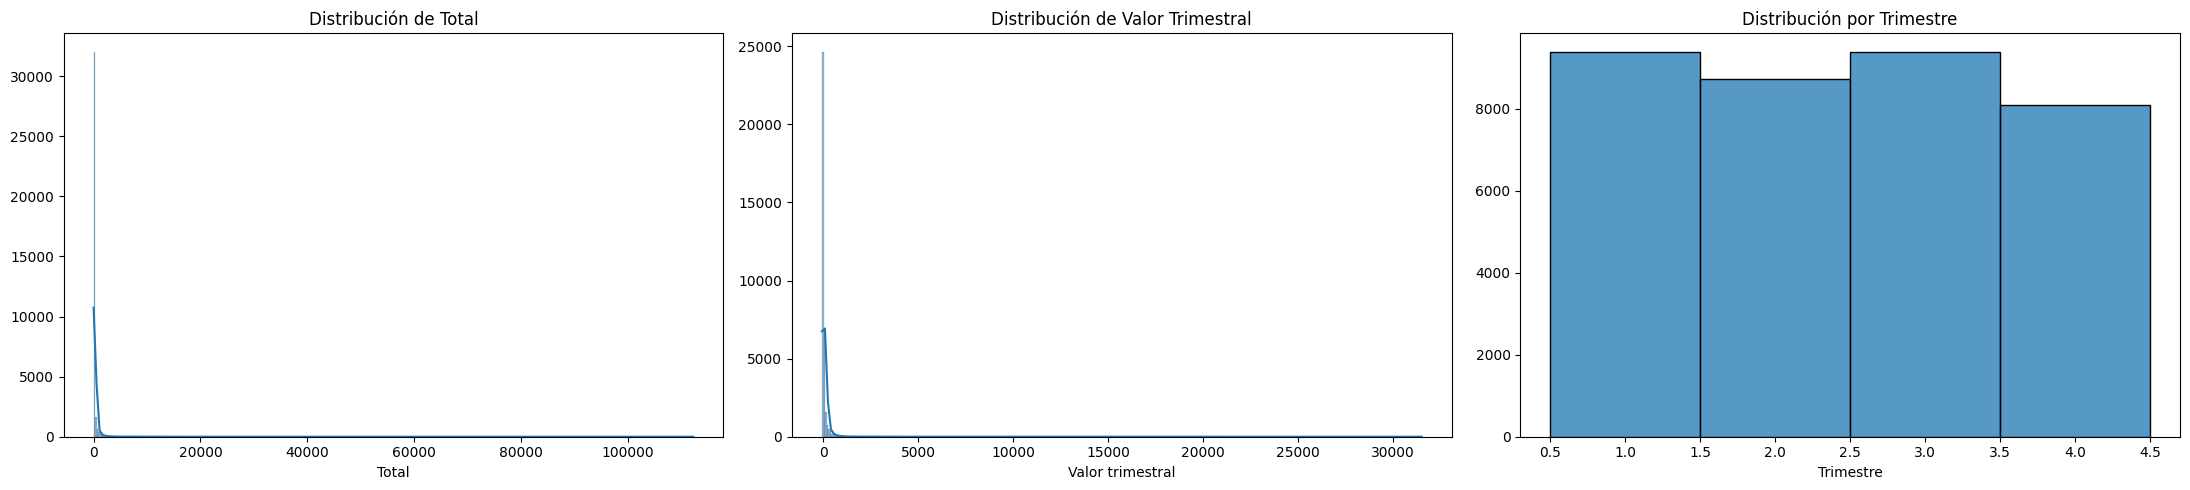

In [348]:
fig, axis = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(ax=axis[0], data=df_5, x='Total', kde=True)
axis[0].set_title('Distribución de Total')
axis[0].set_ylabel(None)

sns.histplot(ax=axis[1], data=df_5, x='Valor trimestral', kde=True)
axis[1].set_title('Distribución de Valor Trimestral')
axis[1].set_ylabel(None)

sns.histplot(ax=axis[2], data=df_5, x='Trimestre', discrete=True)
axis[2].set_title('Distribución por Trimestre')
axis[2].set_ylabel(None)

plt.tight_layout()
plt.show()


## Visualización de variables categóricas

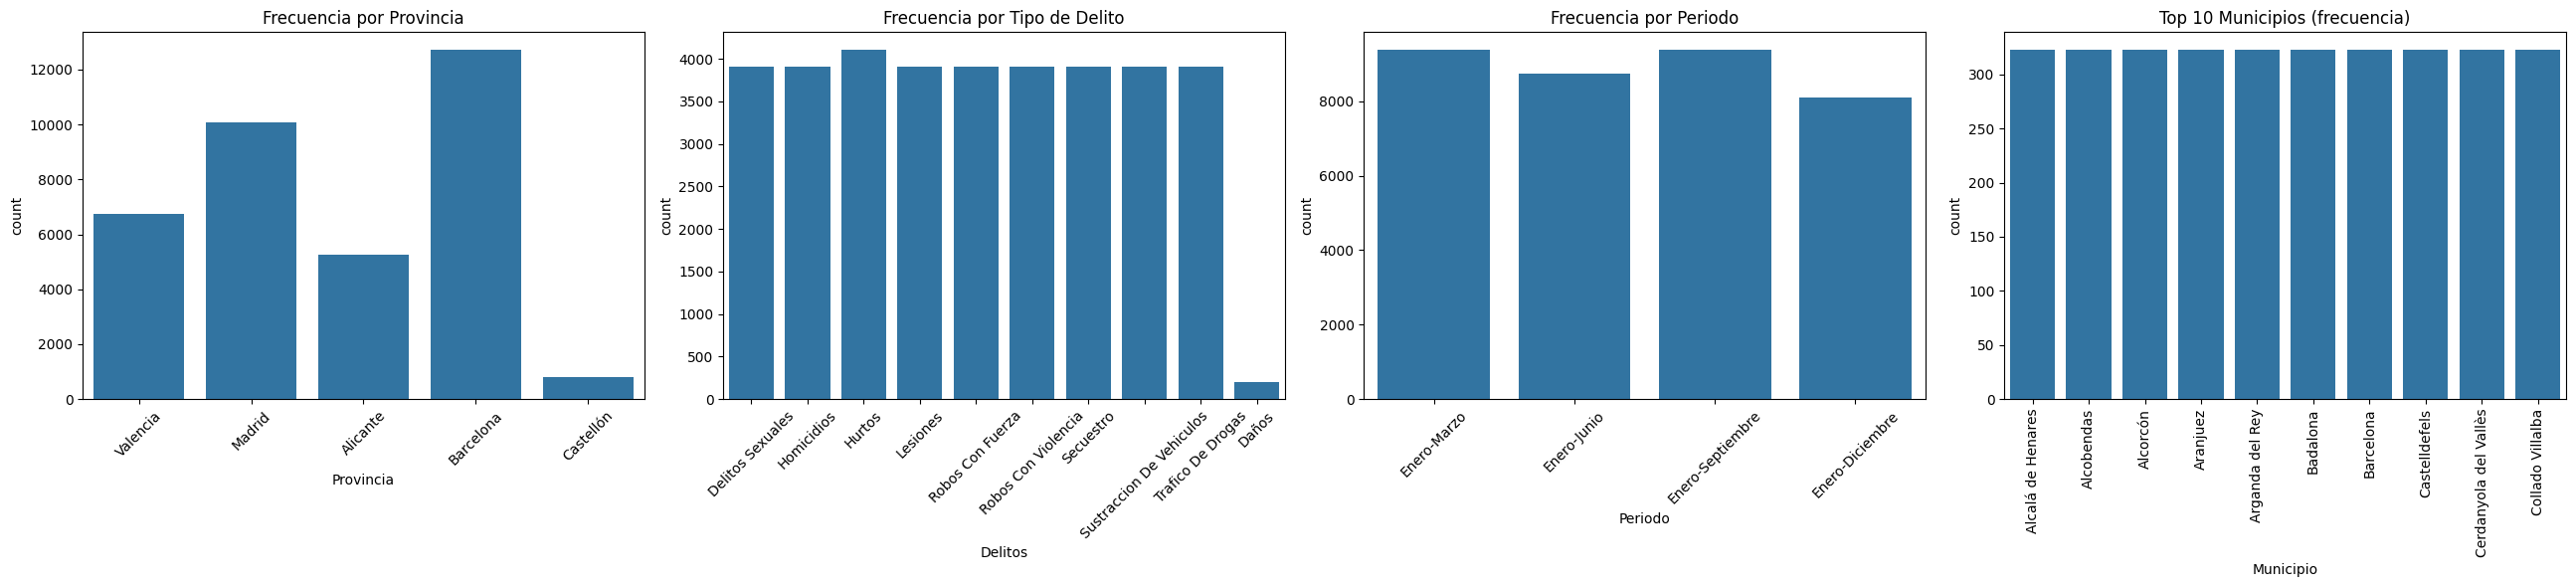

In [349]:
fig, axis = plt.subplots(1, 4, figsize=(26, 6))

sns.countplot(ax=axis[0], data=df_5, x='Provincia')
axis[0].set_title('Frecuencia por Provincia')
axis[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axis[1], data=df_5, x='Delitos')
axis[1].set_title('Frecuencia por Tipo de Delito')
axis[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axis[2], data=df_5, x='Periodo')
axis[2].set_title('Frecuencia por Periodo')
axis[2].tick_params(axis='x', rotation=45)


top_municipios = df_5['Municipio'].value_counts().head(10).index
sns.countplot(
    ax=axis[3],
    data=df_5[df_5['Municipio'].isin(top_municipios)],
    x='Municipio'
)
axis[3].set_title('Top 10 Municipios (frecuencia)')
axis[3].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


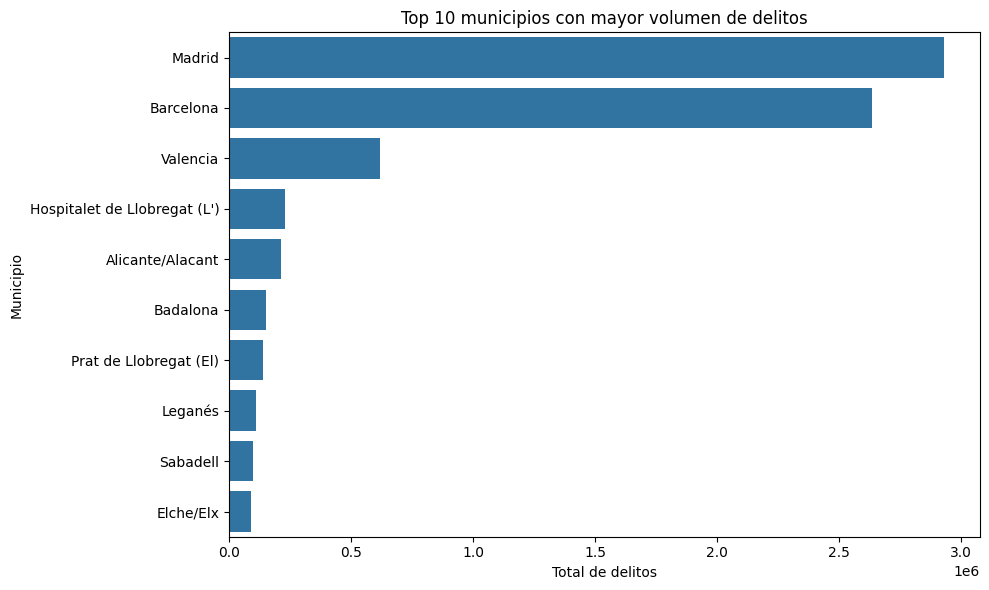

In [350]:
top_municipios = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_municipios.values,y=top_municipios.index)

plt.title('Top 10 municipios con mayor volumen de delitos')
plt.xlabel('Total de delitos')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()


In [351]:
top_municipios_provincia = (df_5.groupby(['Provincia', 'Municipio'])['Total'].sum().reset_index().sort_values(['Provincia', 'Total'], ascending=[True, False]))

top_municipios_provincia.groupby('Provincia').head(10)


,Provincia,Municipio,Total
1,Alicante,Alicante/Alacant,211165
10,Alicante,Elche/Elx,91112
21,Alicante,Torrevieja,83305
5,Alicante,Benidorm,62010
16,Alicante,Orihuela,49404
9,Alicante,Dénia,21616
20,Alicante,Santa Pola,17135
11,Alicante,Elda,16008
0,Alicante,Alcoy/Alcoi,14319
22,Alicante,Villena,10550


## Observaciones y concluciones:

> - Las visualizaciones se organizaron diferenciando variables numéricas y categóricas, utilizando histogramas para analizar distribuciones y gráficos de frecuencia para variables discretas, con el objetivo de mejorar la interpretabilidad del análisis exploratorio.